| 구조                             | 입력   | 출력             | 대표 예제                |
| ------------------------------ | ---- | -------------- | -------------------- |
| One to One                     | 1    | 1              | 일반 ANN, 단일 시점 예측     |
| One to Many                    | 1    | 여러 개           | 이미지 캡셔닝, 음악 생성       |
| Many to One                    | 여러 개 | 1              | 주가 예측, 판매량 예측, 감성 분석 |
| Many to Many (동일 길이)           | 여러 개 | 여러 개(동일 길이)    | 품사 태깅, 시계열 각 시점 예측   |
| Many to Many (Encoder-Decoder) | 여러 개 | 여러 개(길이 다름 가능) | 번역, 요약, 챗봇           |


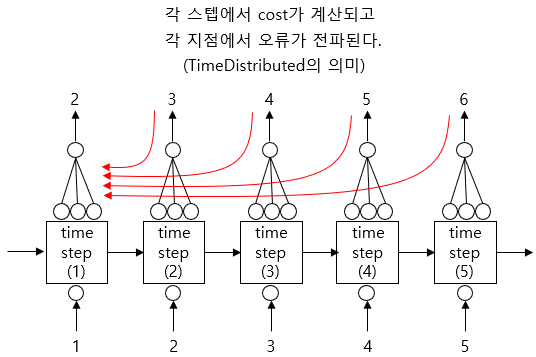

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Input, SimpleRNN, Dense

# ==========================================
# 1. 데이터 준비 (data_size=4, time_steps=2, features=3)
# ==========================================
x = np.array([
    [[170,60,20], [171,61,21]],
    [[180,70,30], [181,71,31]],
    [[190,80,40], [191,81,41]],
    [[200,90,50], [201,91,51]]
])

# 각 시점별 다음 해 예상 키 -> (data_size, time_steps=2, output_dim=1)
y = np.array([
    [[171], [172]],
    [[181], [182]],
    [[191], [192]],
    [[201], [202]]
])

# ==========================================
# 2. 모델 생성
# ==========================================
model = Sequential([
    Input(shape=(2, 3)),
    SimpleRNN(8, activation="relu", return_sequences=True), # 모든 시점의 은닉 상태를 다 출력
    TimeDistributed(Dense(1)) # 각 시점마다 독립적으로 1개의 예측치 출력
])
model.summary()

# ==========================================
# 3. 컴파일 & 4. 학습
# ==========================================
model.compile(optimizer="adam", loss="mse")
model.fit(x, y, epochs=500, verbose=0)

# ==========================================
# 5. 예측
# ==========================================
x_pred = np.array([[[210,95,25], [211,96,26]]])
pred = model.predict(x_pred)

print("\n===== 4. Many-to-Many (동일 길이) 예측 결과 =====")
print("각 시점별 다음 해 예상 키 :\n", pred) # 예상 결과 shape: (1, 2, 1)

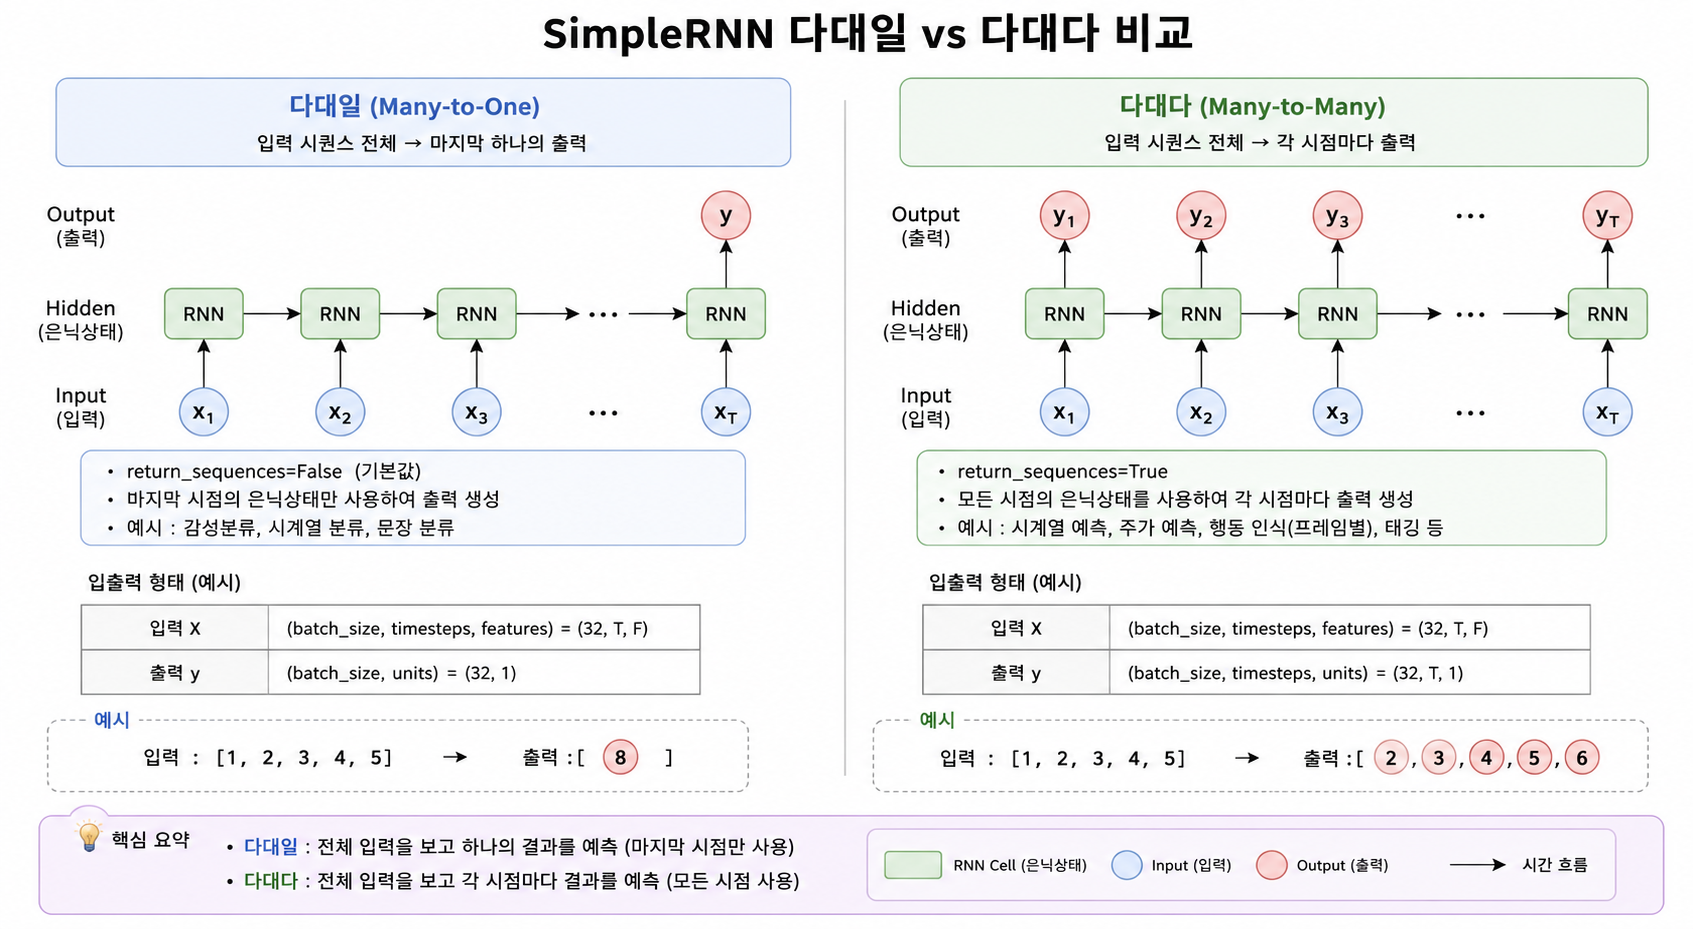

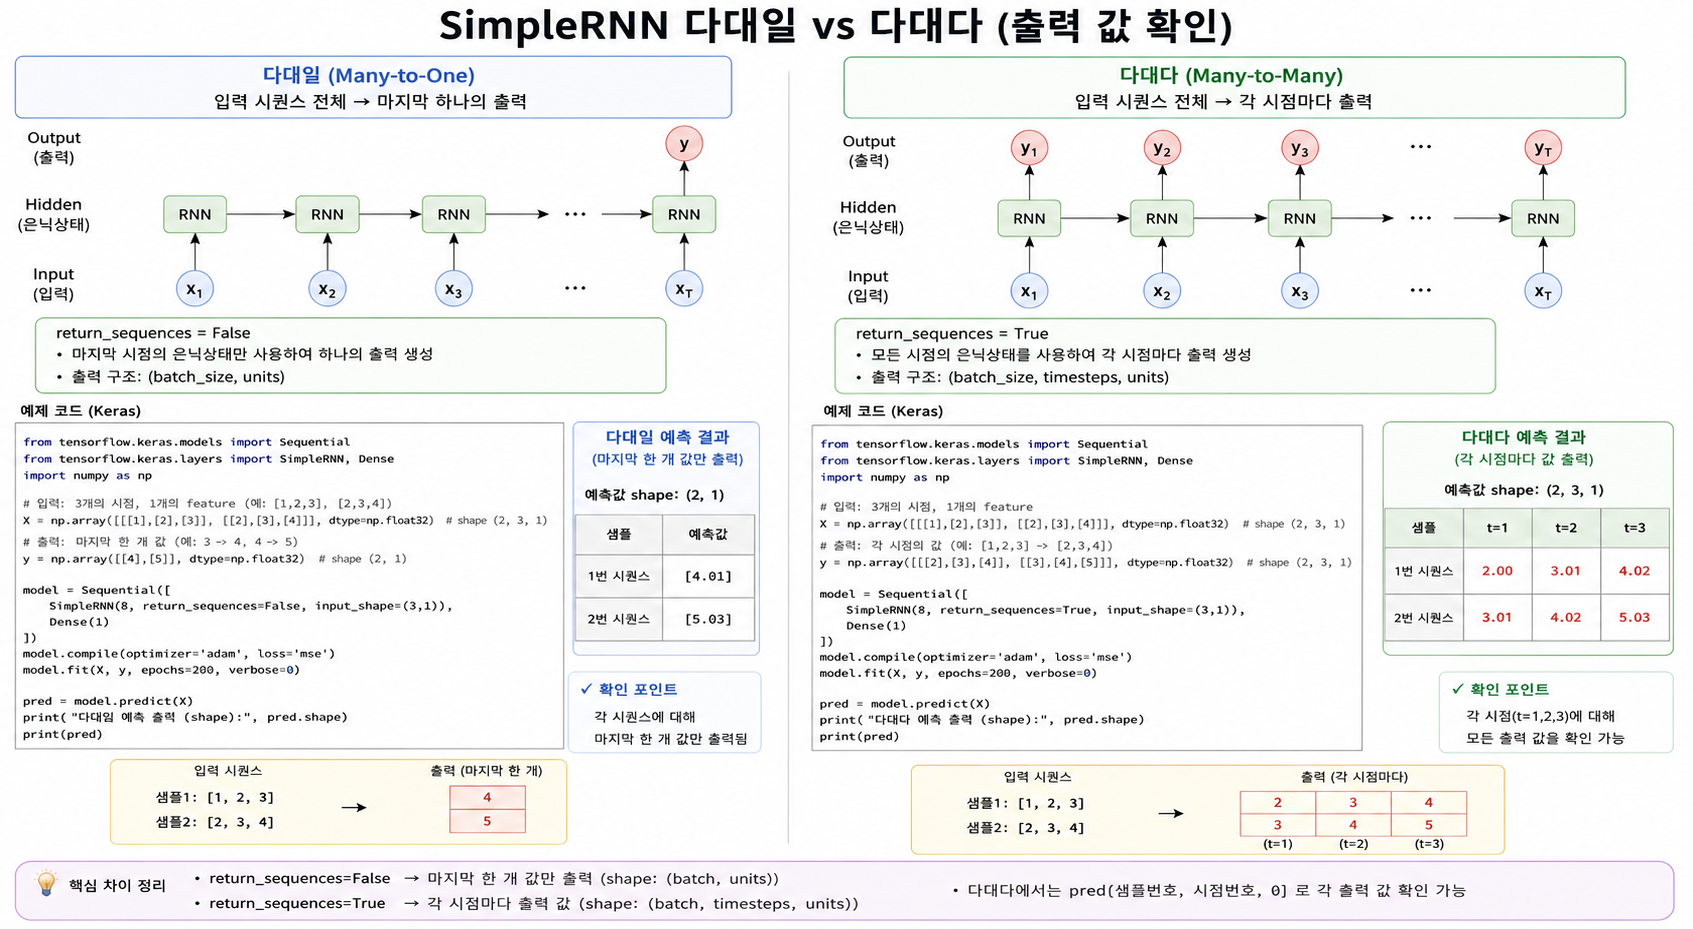

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# =========================
# 1. 데이터 생성 (다대다)
# =========================
X = np.array([
    [[1], [2], [3]],
    [[2], [3], [4]],
    [[3], [4], [5]],
    [[4], [5], [6]],
], dtype=np.float32)

y = np.array([
    [[2], [3], [4]],
    [[3], [4], [5]],
    [[4], [5], [6]],
    [[5], [6], [7]],
], dtype=np.float32)

# | 의미        | 값      |
# | --------- | ------ |
# | samples   | 4개 데이터 |
# | timesteps | 3개 시점  |
# | features  | 1개 값   |


# =========================
# 2. 모델
# =========================
model = Sequential([
    SimpleRNN(16, return_sequences=True, input_shape=(3, 1)),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# =========================
# 3. 학습
# =========================
model.fit(X, y, epochs=200, verbose=1)

# =========================
# 4. 예측
# =========================
test = np.array([[[5], [6], [7]]], dtype=np.float32)

pred = model.predict(test)
print(pred)

# timestep별 출력 보기
for t in range(pred.shape[1]):
    print(f"timestep {t+1}: {pred[0, t, 0]:.4f}")

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 31.2606
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 30.8325
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 30.4084
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 29.9886
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 29.5732
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 29.1625
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 28.7565
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 28.3555
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 27.9595
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 27.5688
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 27.1833
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 26.8032
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 26.4286
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 26.0594
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 25.6957
Epoch 

In [ ]:
# 이 부분은 뺄것
import pandas as pd

pred = model.predict(test)

df = pd.DataFrame({
    "input": [5, 6, 7],
    "pred": pred[0].reshape(-1)
})

print(df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
   input      pred
0      5  2.478018
1      6  4.494274
2      7  4.622665
